##Importing libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##Importing dataset

In [35]:
df = pd.read_csv('/content/PJME_hourly.csv')
df= df.set_index('Datetime')
df.index = pd.to_datetime(df.index)

In [36]:
df

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


In [37]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


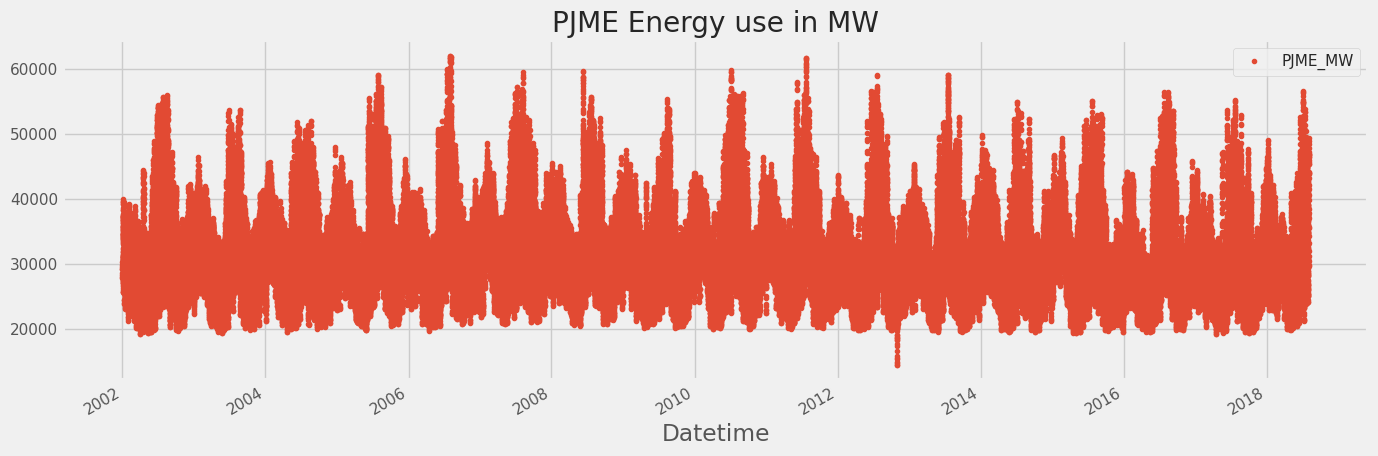

In [38]:
df.plot(style = '.',
        figsize = (15,5),
        color = color_pal[0],
        title = 'PJME Energy use in MW')
plt.show()

##Train/Test Split

In [39]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

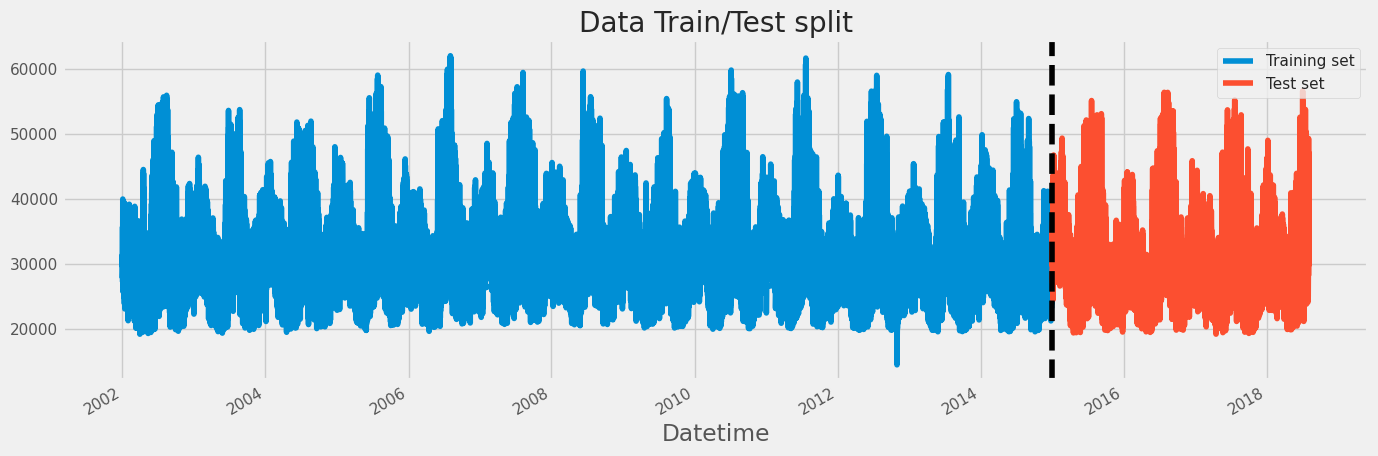

In [40]:
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax = ax, label = 'Training Set')
test.plot(ax = ax, label = 'Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training set', 'Test set'])
plt.title('Data Train/Test split')
plt.show()

In [ ]:
#get an idea of what's one single week of data looks like

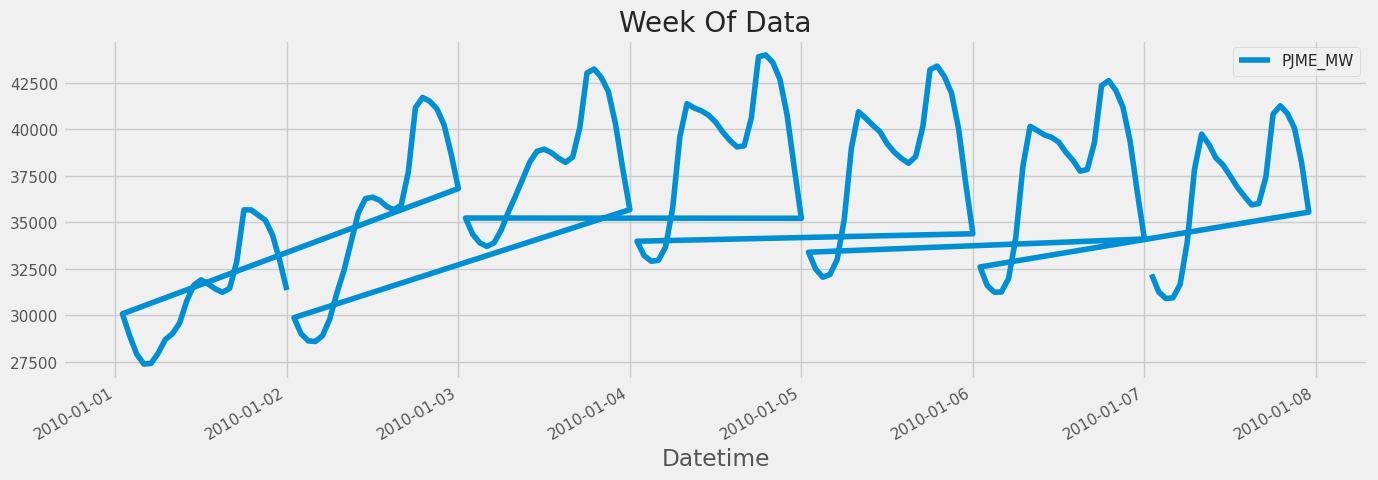

In [41]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

##Feature Creation

In [42]:
def create_features(df): #create time series features based on time series index

  df['hour'] = df.index.hour
  df['dayofweek'] = df.index.day_of_week #the day of the week with Monday=0, Sunday=6
  df['quarter'] = df.index.quarter
  df['month'] = df.index.month
  df['year'] = df.index.year
  df['dayofyear']=df.index.dayofyear
  return df

df = create_features(df)

##Visualize our Feature / Target Relationship

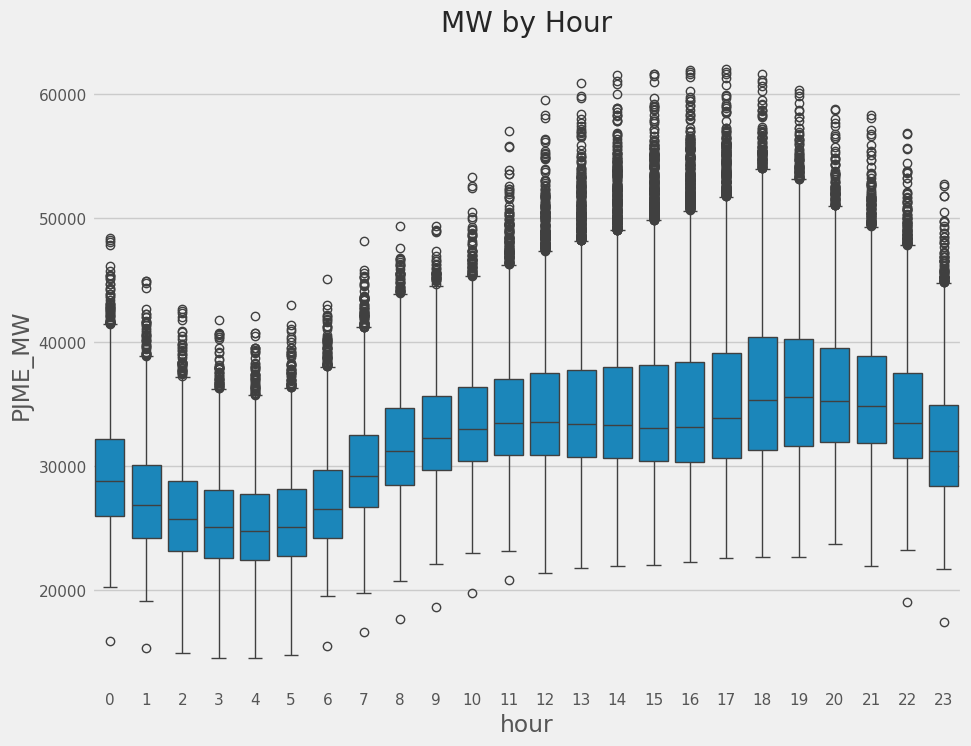

In [43]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()

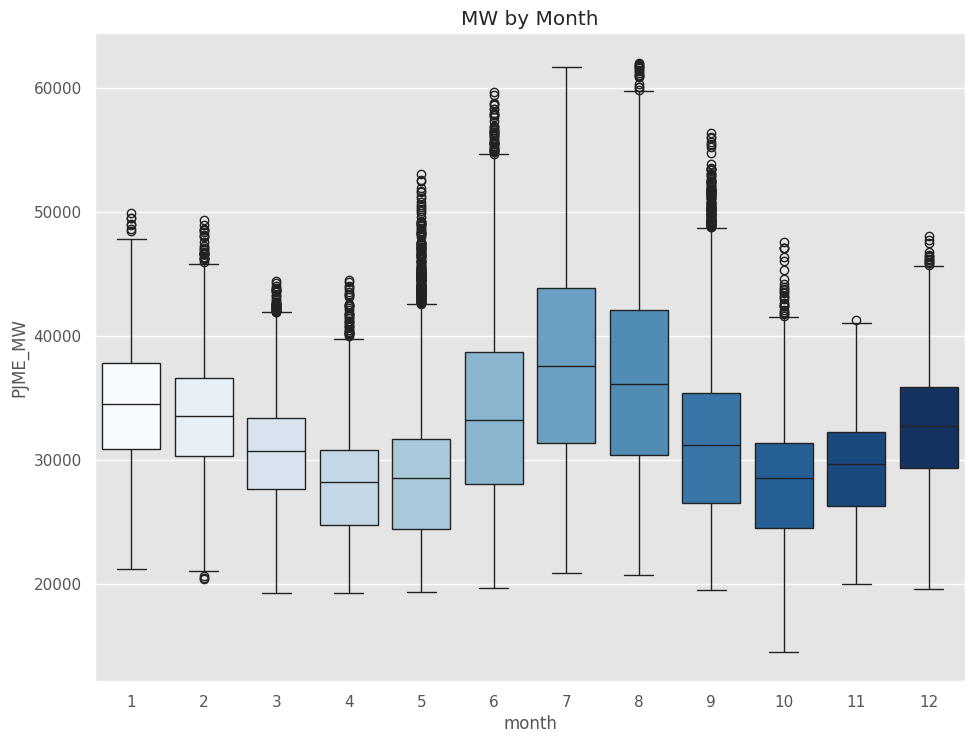

In [72]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', hue='month', y='PJME_MW', palette='Blues', legend=False)
ax.set_title('MW by Month')
plt.show()

In [ ]:
#Energy consumption Each Year

Text(0, 0.5, 'Energy in MW')

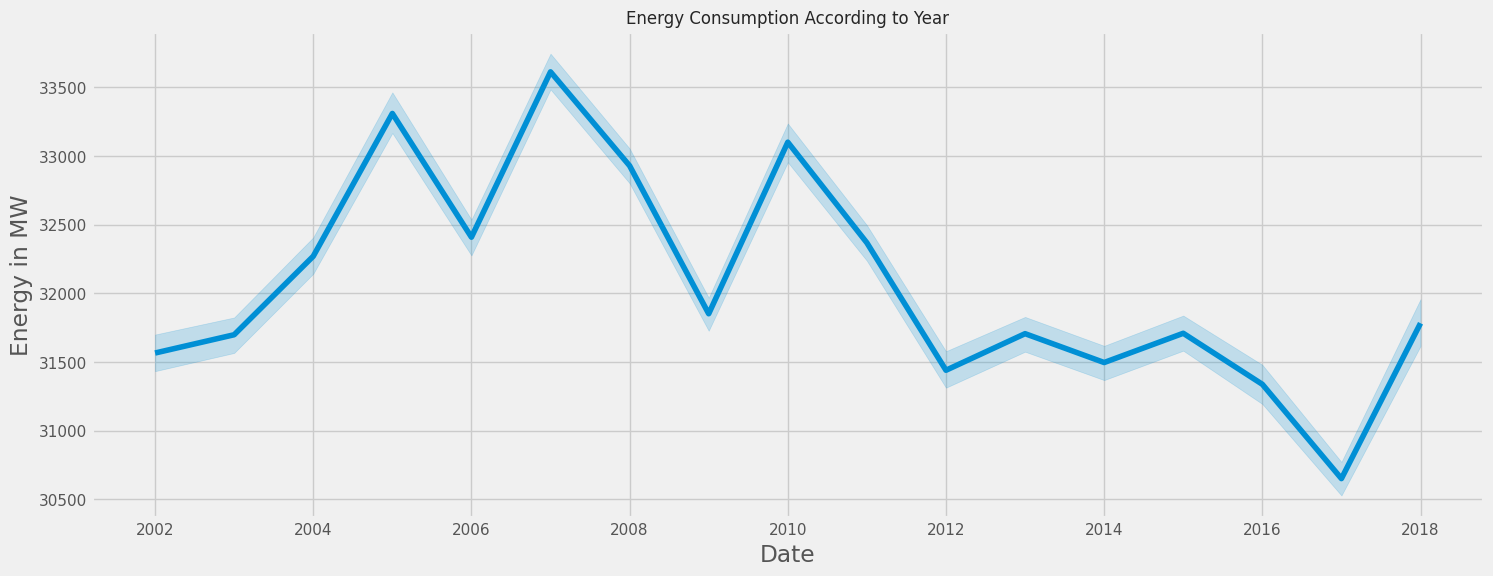

In [45]:
from matplotlib import style
fig = plt.figure()
ax1 = plt.subplot2grid((1,1), (0,0))
style.use('ggplot')

sns.lineplot(x=df["year"], y=df["PJME_MW"], data=df)
sns.set(rc={'figure.figsize':(16,6)})

plt.title("Energy Consumption According to Year")
plt.xlabel("Date")
plt.ylabel("Energy in MW")

##Creating the Model

In [47]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

In [48]:
x_train = train.drop("PJME_MW", axis=1)
y_train = train["PJME_MW"]
x_test = test.drop("PJME_MW", axis=1)
y_test = test["PJME_MW"]

In [49]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

In [50]:
results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

In [51]:
results_df = pd.DataFrame(results).sort_values(by="RMSE")
print(results_df)

               Model          MAE         RMSE        R²
3  Gradient Boosting  2903.171218  3736.984503  0.664291
4            XGBoost  3145.591473  4193.670130  0.577225
2      Random Forest  3201.166775  4339.991102  0.547208
1   Ridge Regression  4600.386964  5683.953152  0.223357
0  Linear Regression  4600.386889  5683.953282  0.223357


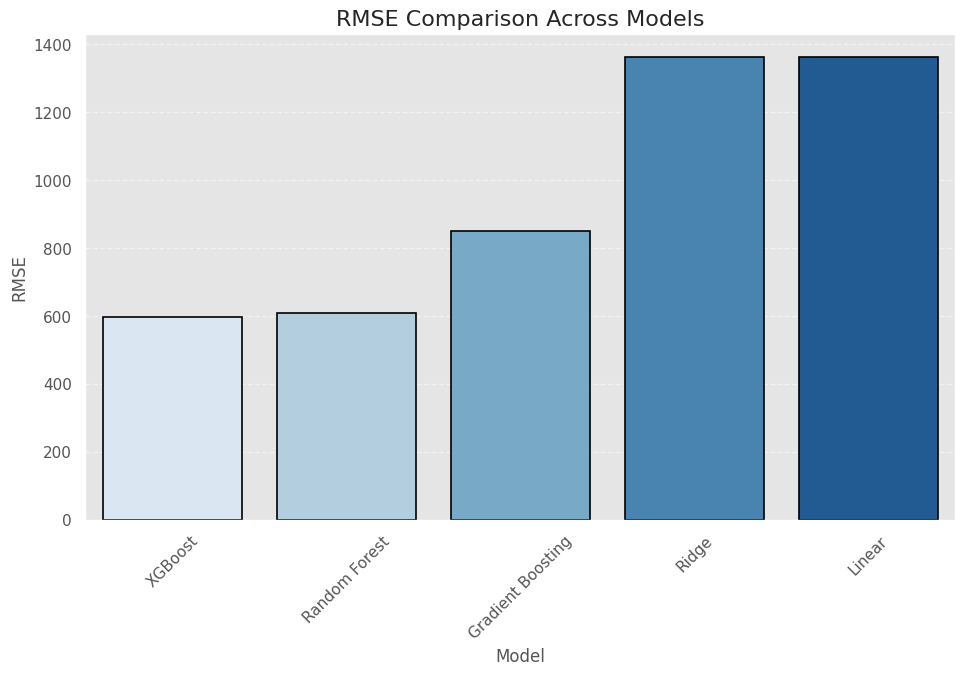

In [70]:
results_df = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest", "Gradient Boosting", "Ridge", "Linear"],
    "RMSE": [596.12, 607.90, 849.84, 1362.83, 1362.83],
    "R²": [0.9915, 0.9911, 0.9826, 0.9554, 0.9554]
})

plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="RMSE", hue='Model', palette="Blues",width=0.8, edgecolor="black", linewidth=1.2, legend=False)
plt.title("RMSE Comparison Across Models", fontsize=16)
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

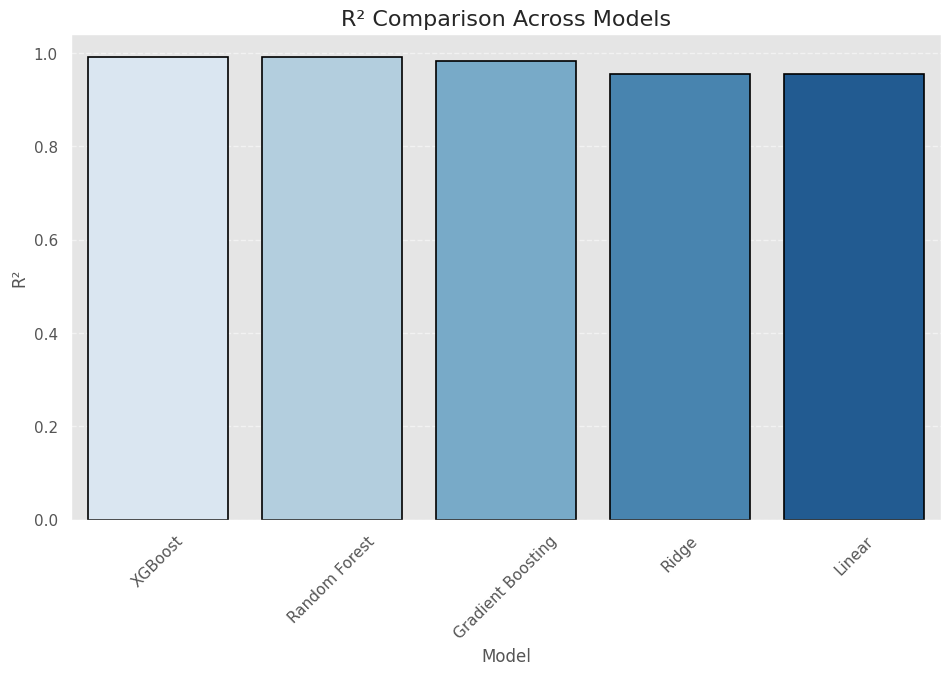

In [68]:
results_df = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest", "Gradient Boosting", "Ridge", "Linear"],
    "RMSE": [596.12, 607.90, 849.84, 1362.83, 1362.83],
    "R²": [0.9915, 0.9911, 0.9826, 0.9554, 0.9554]
})

plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="R²", palette="Blues", hue="Model", width=0.8, edgecolor="black", linewidth=1.2, legend=False)
plt.title("R² Comparison Across Models", fontsize=16)
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()